# Temperature Color Schemes

Download HRRR forecast-hour-zero 2m temperature and compare three temperature color schemes on the same map scale.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import os

repo_tmp = Path("tmp").resolve()
data_dir = Path("data").resolve()
(repo_tmp / "matplotlib").mkdir(parents=True, exist_ok=True)
(repo_tmp / "herbie-config").mkdir(parents=True, exist_ok=True)
(repo_tmp / "cache").mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(repo_tmp / "matplotlib"))
os.environ.setdefault("HERBIE_CONFIG_PATH", str(repo_tmp / "herbie-config"))
os.environ.setdefault("XDG_CACHE_HOME", str(repo_tmp / "cache"))

import numpy as np
import pandas as pd
import xarray as xr
from herbie import Herbie

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# HRRR fxx=0 is valid at exactly this model run time.
valid_time_utc = datetime(2026, 6, 2, 18, 0, tzinfo=timezone.utc)

# CONUS plotting bounds: west, east, south, north.
map_extent = [-125.0, -66.5, 24.0, 50.0]

# Plot every Nth HRRR grid point so Cartopy renders quickly.
hrrr_plot_stride = 5

In [3]:
def download_hrrr_2m_temperature(valid_time):
    """Download HRRR forecast-hour-zero 2m temperature and return a compact dataset."""
    run_time = pd.Timestamp(valid_time).tz_convert("UTC").tz_localize(None).to_pydatetime()

    hrrr = Herbie(run_time, model="hrrr", product="sfc", fxx=0, save_dir=data_dir)
    subset_path = hrrr.download(":TMP:2 m above ground:", verbose=False)
    if isinstance(subset_path, (list, tuple)):
        subset_path = subset_path[0]

    ds = xr.open_dataset(
        subset_path,
        engine="cfgrib",
        backend_kwargs={"indexpath": ""},
    )

    if "t2m" not in ds:
        raise KeyError(f"Expected HRRR variable 't2m', found {list(ds.data_vars)}")

    temp_c = (ds["t2m"].squeeze() - 273.15).load()
    latitude = ds["latitude"].load()
    longitude = (((ds["longitude"] + 180.0) % 360.0) - 180.0).load()
    ds.close()

    return xr.Dataset(
        data_vars={"t2m_c": temp_c},
        coords={
            "latitude": latitude,
            "longitude": longitude,
        },
        attrs={
            "model": "HRRR",
            "product": "sfc",
            "forecast_hour": 0,
            "valid_time_utc": pd.Timestamp(valid_time).isoformat(),
            "grib_subset_path": str(subset_path),
        },
    )


hrrr_ds = download_hrrr_2m_temperature(valid_time_utc)
hrrr_ds

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-02 18:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


<xarray.Dataset> Size: 38MB
Dimensions:            (y: 1059, x: 1799)
Coordinates:
    latitude           (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
    longitude          (y, x) float64 15MB -122.7 -122.7 ... -60.95 -60.92
    time               datetime64[ns] 8B 2026-06-02T18:00:00
    step               timedelta64[ns] 8B 00:00:00
    heightAboveGround  float64 8B 2.0
    valid_time         datetime64[ns] 8B 2026-06-02T18:00:00
Dimensions without coordinates: y, x
Data variables:
    t2m_c              (y, x) float32 8MB 22.15 22.15 22.15 ... 4.029 4.092
Attributes:
    model:             HRRR
    product:           sfc
    forecast_hour:     0
    valid_time_utc:    2026-06-02T18:00:00+00:00
    grib_subset_path:  /home/dmmsp/Projects/observations-vs-forecasts/data/hr...

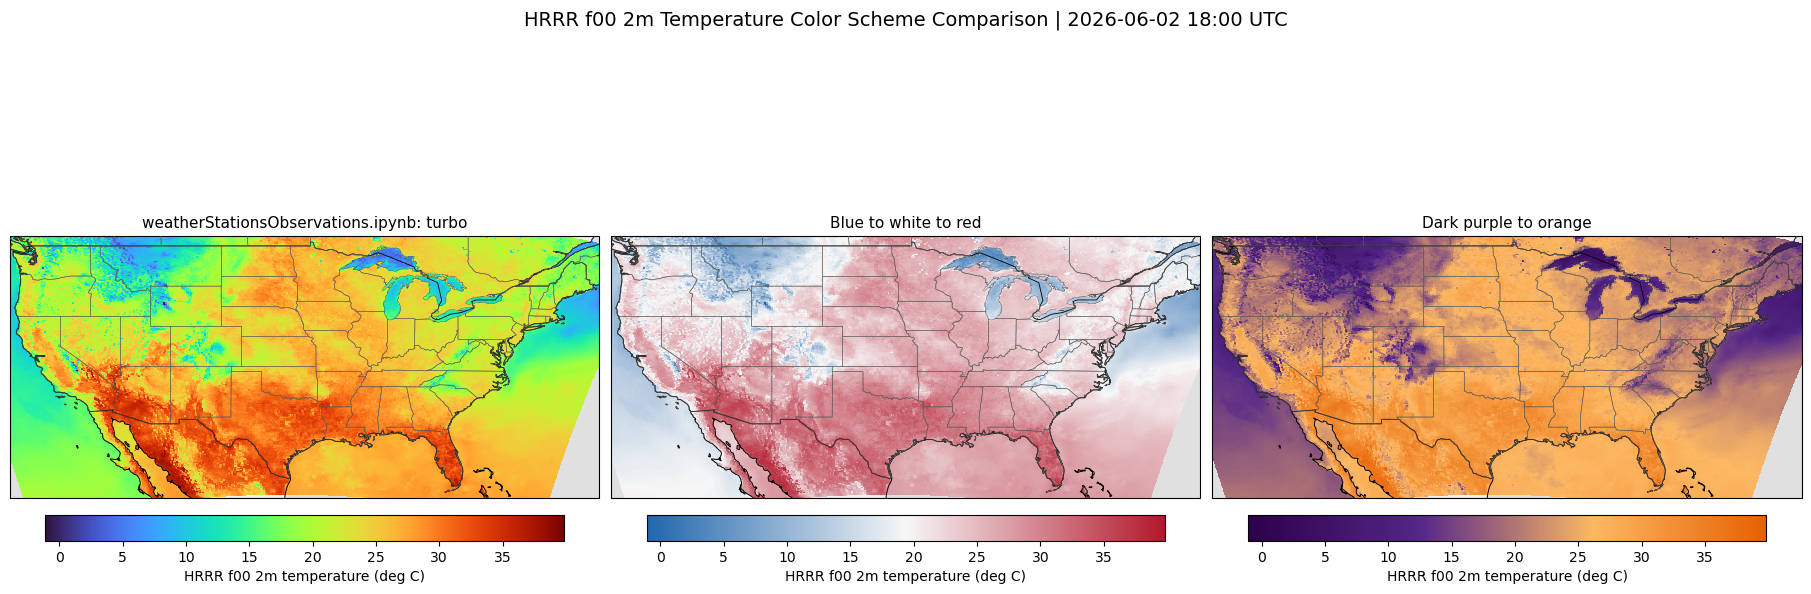

In [4]:
hrrr_plot = hrrr_ds.isel(
    y=slice(None, None, hrrr_plot_stride),
    x=slice(None, None, hrrr_plot_stride),
)

temperature_vmin_c = float(hrrr_plot["t2m_c"].min())
temperature_vmax_c = float(hrrr_plot["t2m_c"].max())
valid_label = pd.Timestamp(valid_time_utc).strftime("%Y-%m-%d %H:%M UTC")


temperature_color_schemes = {
    "weather_stations": {
        "label": "weatherStationsObservations.ipynb: turbo",
        "cmap": "turbo",
    },
    "blue_white_red": {
        "label": "Blue to white to red",
        "cmap": LinearSegmentedColormap.from_list(
            "temperature_blue_white_red",
            ["#2166ac", "#f7f7f7", "#b2182b"],
        ),
    },
    "purple_orange": {
        "label": "Dark purple to orange",
        "cmap": LinearSegmentedColormap.from_list(
            "temperature_dark_purple_orange",
            ["#2d004b", "#542788", "#fdb863", "#e66101"],
        ),
    },
}


def add_map_features(ax):
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="0.94", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="0.88", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, zorder=3)
    ax.add_feature(cfeature.STATES, linewidth=0.35, edgecolor="0.35", zorder=3)


def plot_temperature(
    ax,
    hrrr_temperature,
    color_scheme="weather_stations",
    vmin=temperature_vmin_c,
    vmax=temperature_vmax_c,
):
    """Plot HRRR 2m temperature with one named color scheme."""
    if color_scheme not in temperature_color_schemes:
        options = ", ".join(temperature_color_schemes)
        raise ValueError(f"Unknown color_scheme={color_scheme!r}. Choose one of: {options}")

    scheme = temperature_color_schemes[color_scheme]
    add_map_features(ax)
    mesh = ax.pcolormesh(
        hrrr_temperature["longitude"],
        hrrr_temperature["latitude"],
        hrrr_temperature["t2m_c"],
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=scheme["cmap"],
        vmin=vmin,
        vmax=vmax,
        zorder=1,
    )
    ax.set_title(scheme["label"], fontsize=11)
    return mesh


fig, axes = plt.subplots(
    1,
    len(temperature_color_schemes),
    figsize=(18, 5.8),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

for ax, color_scheme in zip(axes, temperature_color_schemes):
    mesh = plot_temperature(ax, hrrr_plot, color_scheme=color_scheme)
    colorbar = fig.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.03, shrink=0.88)
    colorbar.set_label("HRRR f00 2m temperature (deg C)")

fig.suptitle(
    f"HRRR f00 2m Temperature Color Scheme Comparison | {valid_label}",
    fontsize=14,
)
plt.show()